<a href="https://colab.research.google.com/github/Alxshax05/Northstar-Logistics-analysis/blob/main/notebooks/python_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip -o "/content/northstar_dataset (3).zip"

Archive:  /content/northstar_dataset (3).zip
   creating: northstar_dataset/
  inflating: northstar_dataset/app_events.csv  
  inflating: northstar_dataset/complaints.csv  
  inflating: northstar_dataset/customers.csv  
  inflating: northstar_dataset/data_dictionary.csv  
  inflating: northstar_dataset/deliveries.csv  
  inflating: northstar_dataset/drivers.csv  
  inflating: northstar_dataset/hubs.csv  
  inflating: northstar_dataset/incidents.csv  
  inflating: northstar_dataset/orders.csv  
  inflating: northstar_dataset/README.txt  
  inflating: northstar_dataset/vehicles.csv  


#Python processing
# The aim in this is to clean our data set Northstar logistics. The data from orders, customers and deliveries was combined into one dataset, making it easier to interpret.



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!ls


 northstar_dataset  'northstar_dataset (3).zip'   sample_data


In [3]:
import pandas as pd

orders = pd.read_csv("northstar_dataset/orders.csv")
deliveries = pd.read_csv("northstar_dataset/deliveries.csv")
customers = pd.read_csv("northstar_dataset/customers.csv")
complaints = pd.read_csv("northstar_dataset/complaints.csv")

print("ORDERS")
print(orders.columns)

print("\nDELIVERIES")
print(deliveries.columns)

print("\nCUSTOMERS")
print(customers.columns)

print("\nCOMPLAINTS")
print(complaints.columns)

ORDERS
Index(['order_id', 'customer_id', 'service_type', 'order_created_at',
       'promised_window_hours', 'pickup_zone', 'dropoff_zone',
       'priority_level', 'order_value', 'booking_channel',
       'special_handling_flag'],
      dtype='object')

DELIVERIES
Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')

CUSTOMERS
Index(['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date',
       'loyalty_score', 'app_engagement_score', 'preferred_channel',
       'account_status'],
      dtype='object')

COMPLAINTS
Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')


# Data Integration
# Here we will merge our datasets using common identifiers. Creating an easier accessible dataset, made to analyse simpler.

In [4]:
df = orders.merge(
    deliveries,
    on="order_id",
    how="left"
)

df = df.merge(
    customers,
    on="customer_id",
    how="left"
)

print(df.shape)
df.head()

(1250, 31)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,customer_rating_post_delivery,fuel_or_charge_cost,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,4.29,15.82,24,South,Consumer,2025-03-02 11:24:00,73.2,57.9,App,Active
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,...,NaN,NaN,20,WEST,Consumer,2024-09-23 21:00:00,56.1,62.6,App,Dormant
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,...,3.70,13.16,42,north,Consumer,2024-06-07 22:41:00,87.1,36.6,App,Active
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,...,5.00,13.41,50,NORTH,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,...,4.38,13.53,23,SOUTH,Consumer,2024-06-29 19:47:00,64.3,38.5,Phone,Active


In [5]:
df.isnull().sum()

,0
order_id,0
customer_id,0
service_type,0
order_created_at,0
promised_window_hours,0
pickup_zone,0
dropoff_zone,0
priority_level,0
order_value,0
booking_channel,25


In [6]:
df.drop_duplicates(inplace=True)

print("Rows after removing duplicates:")
print(df.shape)

Rows after removing duplicates:
(1250, 31)


In [9]:
df["order_created_at"] = pd.to_datetime(df["order_created_at"])

df["dispatch_time"] = pd.to_datetime(df["dispatch_time"])

df["delivery_completed_at"] = pd.to_datetime(
    df["delivery_completed_at"]
)

In [10]:
df["delivery_hours"] = (
    df["delivery_completed_at"] -
    df["dispatch_time"]
).dt.total_seconds()/3600

In [13]:
df["late_delivery"] = np.where(
    df["delivery_status"] == "Late",
    1,
    0
)

In [14]:
df[
    [
        "order_value",
        "route_distance_km",
        "fuel_or_charge_cost",
        "delivery_hours"
    ]
].describe()

,order_value,route_distance_km,fuel_or_charge_cost,delivery_hours
count,1250.000000,950.000000,950.000000,931.000000
mean,91.050520,13.909316,12.841295,9.545486
std,60.917783,7.477907,4.336468,8.648622
min,2.040000,1.200000,2.500000,-2.214477
25%,47.915000,9.135000,9.925000,2.945854
50%,76.530000,12.840000,12.645000,7.074356
75%,121.097500,16.835000,15.697500,14.643664
max,510.060000,41.940000,29.430000,43.456918


# Charts
# Below i have generated charts to analyse delivery outcomes and order value patterns across service types.

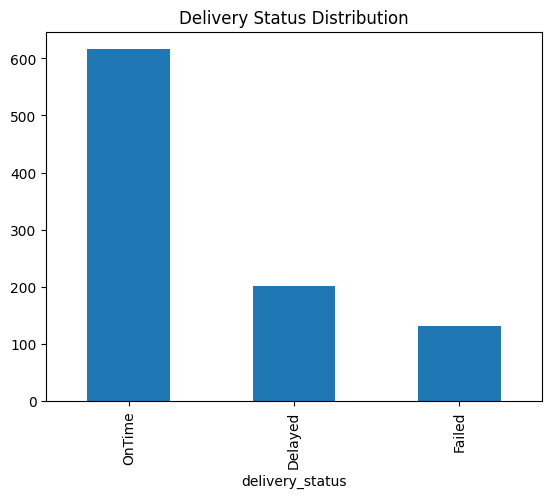

In [15]:
df["delivery_status"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Delivery Status Distribution"
)

plt.show()

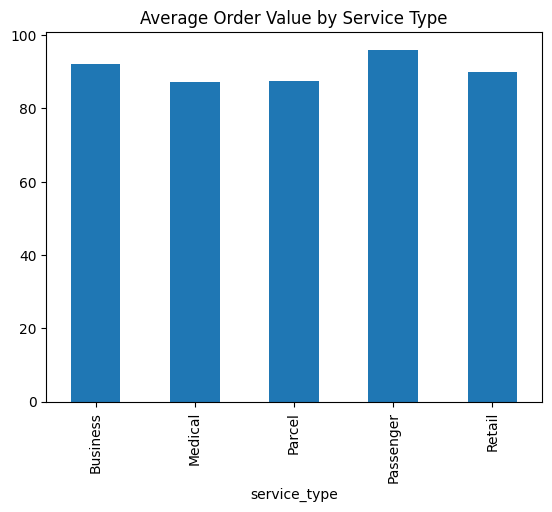

In [16]:
df.groupby(
    "service_type"
)["order_value"].mean().plot(
    kind="bar"
)

plt.title(
    "Average Order Value by Service Type"
)

plt.show()

In [17]:
df.to_csv(
    "cleaned_northstar.csv",
    index=False
)

print("File saved")

File saved


In [18]:
from google.colab import files

files.download("cleaned_northstar.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final conclusion
# Through this we have successfully merged our original dataset inot a single dataset containing 1250 records. We created additional features to support our analysis. Finally we created bar charts to represent the differences in delivery outcomes and Service performers.